## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from sympy import init_printing
from sympy.utilities.lambdify import lambdify
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
from matplotlib import cm  # colormap
init_printing(use_latex=True)

## Discretization

In [2]:
#set the element number for each direction square mesh
element_x = 101 #set for x element 
element_y = element_x #set for y element
a,b = 0,2   #set for x upper and lower bound
c,d = a,b   #set for y upper and lower bound
rho = 1     #set the density
nu = 0.01  #set the kinematic viscosity
t = 10
convergence_res = 0.001 #smaller means the source term diffuse better

#set the spacing for dx and dy
dx = (b-a)/(element_x-1)    #set for delta x
dy = (d-c)/(element_y-1)    #set for delta y
dt = 0.001

#set for x and y space respectively
x_vals = np.linspace(a,b,element_x)  #set for x
y_vals = np.linspace(c,d,element_y)  #set for y
X,Y = np.meshgrid(x_vals,y_vals)

#set initial condition, we perserve initial guessing
u_to = np.zeros([element_y,element_x]) #set the parameters u
v_to = np.zeros([element_y,element_x]) #set the parameters v
p_to = np.zeros([element_y,element_x]) #set the parameters p

## Pressure Term Eq

In [3]:
def Pressure_Numerically(u_to,v_to,dx,dy,p,rho,dt,convergence_res):

    l1norm = 1  #initialize value
    convergence = []    #store residual

    while l1norm > convergence_res:

        p_new = p.copy()
        #we calculate the horizontal first then vertically declined after the horizontal is done
        for i in range (1,len(p[:,0])-1): #define the y each iteration

            for j in range (1,len(p[0])-1): #define the x each iteration

                #numeric poisson procedure
                p_new[i, j] = (
                    ((p[i, j+1] + p[i, j-1]) * dy**2 +
                     (p[i+1, j] + p[i-1, j]) * dx**2)
                    / (2 * (dx**2 + dy**2))
                    - (rho * dx**2 * dy**2) / (2 * (dx**2 + dy**2)) * (
                        (1/dt) * (
                            (u_to[i, j+1] - u_to[i, j-1]) / (2*dx) +
                            (v_to[i+1, j] - v_to[i-1, j]) / (2*dy)
                        )
                        - ((u_to[i, j+1] - u_to[i, j-1]) / (2*dx))**2
                        - 2 * (
                            (u_to[i+1, j] - u_to[i-1, j]) / (2*dy) *
                            (v_to[i, j+1] - v_to[i, j-1]) / (2*dx)
                        )
                        - ((v_to[i+1, j] - v_to[i-1, j]) / (2*dy))**2
                    )
                )
            
        p_new[:,0] = p_new[:,1]      #set the x = 0 ,dP = 0 neumann boundary
        p_new[:,-1] = p_new[:,-2]       #set the x = 2 ,dP = 0 neumann boundary
        p_new[0, :] = p_new[1,:]  #set the y = 0 , dP = 0 neumann boundary
        p_new[-1,:] = 0 #set the y = 2 dirichlet boundary

        #calculate the error and pass to next calculation to reduce error
        l1norm = np.abs(np.sum(np.abs(p_new[:]) - np.abs(p[:]))/(np.sum(np.abs(p[:]))) + 1e-10) 
        print(f'convergence residual: {l1norm}')
        p = p_new

    return p_new

## Construct the Momentum Eq

In [4]:
#construct the numerical framework of 2d convection equation
def Momentum_Numerically(u_to,v_to,p_to,dx,dy,dt,nu,rho,convergence_res):

    U = []  #tensor to save all the u data spaciotemporal
    V = []  #tensor to save all the v data spaciotemporal
    P = []  #tensor to save all the p data spaciotemporal

    for k in range (0,int(t/dt)):

        print (f'timestep : {k}')
        u_new = u_to.copy() #copy to get identic matrices then by next line we manipulate each column and row by numeric procedure
        v_new = v_to.copy() #copy to get identic matrices then by next line we manipulate each column and row by numeric procedure

        p_new = Pressure_Numerically(u_to,v_to,dx,dy,p_to,rho,dt,convergence_res) #set the pressure distribution

        #we calculate the horizontal first then vertically declined after the horizontal is done
        #numeric burger procedure
        for i in range (1,len(u_to[:,0])-1): #define the y each iteration

            for j in range (1,len(u_to[0])-1): #define the x each iteration
                u_new[i, j] = (
                    u_to[i, j]
                    - dt * u_to[i, j] * (u_to[i, j] - u_to[i, j-1]) / dx   # ∂u/∂x
                    - dt * v_to[i, j] * (u_to[i, j] - u_to[i-1, j]) / dy   # ∂u/∂y
                    - dt / (rho * 2*dx) * (p_new[i, j+1] - p_new[i, j-1])  # ∂p/∂x
                    + nu * dt * (
                        (u_to[i, j+1] - 2*u_to[i, j] + u_to[i, j-1]) / dx**2
                        + (u_to[i+1, j] - 2*u_to[i, j] + u_to[i-1, j]) / dy**2
                    )
                )

                v_new[i, j] = (
                    v_to[i, j]
                    - dt * u_to[i, j] * (v_to[i, j] - v_to[i, j-1]) / dx   # ∂v/∂x
                    - dt * v_to[i, j] * (v_to[i, j] - v_to[i-1, j]) / dy   # ∂v/∂y
                    - dt / (rho * 2*dy) * (p_new[i+1, j] - p_new[i-1, j])  # ∂p/∂y
                    + nu * dt * (
                        (v_to[i, j+1] - 2*v_to[i, j] + v_to[i, j-1]) / dx**2
                        + (v_to[i+1, j] - 2*v_to[i, j] + v_to[i-1, j]) / dy**2
                    )
                )
                
                #c_u = u_new[i,j]*dt/dx
                #c_v = v_new[i,j]*dt/dy
                #print (f'courant number: {np.mean([c_u,c_v])}')

        #set the boundary condition
        u_new[0,:] = 0        #at y = 0 u = 0
        u_new[-1,:] = 1       #at y = 2 u = 1
        u_new[:,0] = 0      #at x = 0 u = 0
        u_new[:,-1] = 0     #at x = 2 u = 0     
        
        v_new[0,:] = 0        #at y = 0 v = 0
        v_new[-1,:] = 0       #at y = 2 v = 0
        v_new[:,0] = 0      #at x = 0 v = 0
        v_new[:,-1] = 0     #at x = 2 v = 0

        cfl_u = np.max(np.abs(u_new)) * dt / dx
        cfl_v = np.max(np.abs(v_new)) * dt / dy
        cfl = max(cfl_u, cfl_v)
        print(f"Max CFL: {cfl:.3e}")

        #store each timestep iteration
        U.append(u_new) 
        V.append(v_new)
        P.append(p_new)
        #input the u after each timestep and refresh to next timestep
        u_to = u_new
        v_to = v_new
        p_to = p_new

    return U,V,P

U_xyt,V_xyt,P_xyt = Momentum_Numerically(u_to,v_to,p_to,dx,dy,dt,nu,rho,convergence_res)

timestep : 0
convergence residual: nan
Max CFL: 5.000e-02
timestep : 1
convergence residual: nan
Max CFL: 5.000e-02
timestep : 2
convergence residual: inf


C:\Users\altha\AppData\Local\Temp\ipykernel_68508\537561556.py:39: RuntimeWarning: invalid value encountered in scalar divide
  l1norm = np.abs(np.sum(np.abs(p_new[:]) - np.abs(p[:]))/(np.sum(np.abs(p[:]))) + 1e-10)
C:\Users\altha\AppData\Local\Temp\ipykernel_68508\537561556.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  l1norm = np.abs(np.sum(np.abs(p_new[:]) - np.abs(p[:]))/(np.sum(np.abs(p[:]))) + 1e-10)


convergence residual: 0.6250000000999999
convergence residual: 0.3076923077923077
convergence residual: 0.1948529412764706
convergence residual: 0.14307692317692305
convergence residual: 0.11137281302059221
convergence residual: 0.0914320315865274
convergence residual: 0.07701976431636613
convergence residual: 0.06666264245985348
convergence residual: 0.058539737135709584
convergence residual: 0.05225277011831084
convergence residual: 0.047075445036289534
convergence residual: 0.04287412321252703
convergence residual: 0.039300161299106705
convergence residual: 0.036303267026777934
convergence residual: 0.033694138336630784
convergence residual: 0.03145304830409022
convergence residual: 0.029467762788486278
convergence residual: 0.027730900798779212
convergence residual: 0.026171384498219635
convergence residual: 0.024787108599491254
convergence residual: 0.02353069118696767
convergence residual: 0.022402323953777854
convergence residual: 0.02136909904098114
convergence residual: 0.0204

## Visualization U

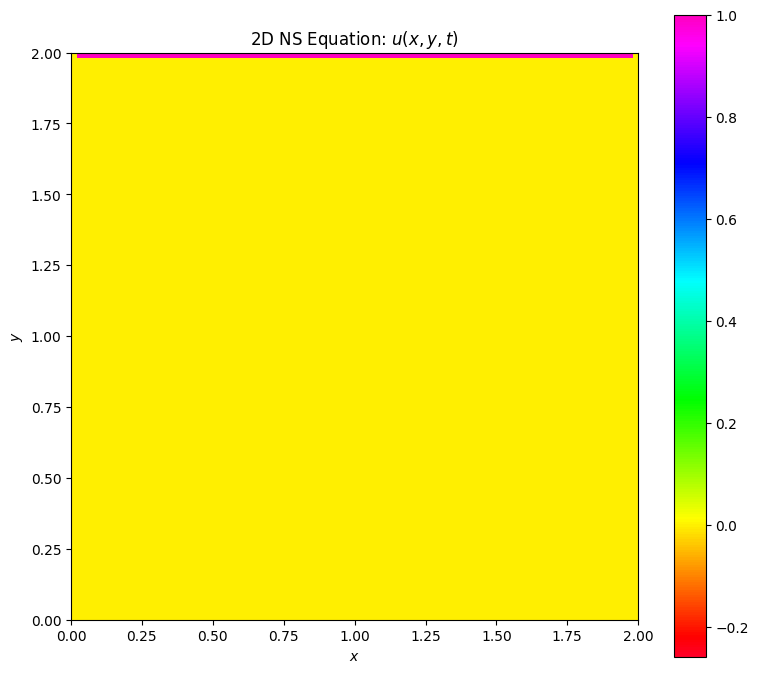

In [ ]:
import matplotlib
fig, ax = plt.subplots(figsize=(8,7))
matplotlib.rcParams['animation.embed_limit'] = 200 #in mb

# Inisialisasi heatmap awal
cax = ax.imshow(U_xyt[0], cmap='gist_rainbow', origin='lower', extent=[0, 2, 0, 2], vmin=np.min(U_xyt), vmax=np.max(U_xyt))
fig.colorbar(cax, ax=ax)
ax.set_title('2D NS Equation: $u(x, y, t)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

def animate(n):
    cax.set_data(U_xyt[n])
    ax.set_title(f'2D Burger Equation $u(x, y, t)$ at t = {n}')
    return cax,

ani = animation.FuncAnimation(fig, animate, frames=len(U_xyt), interval=30, blit=False)
#ani.save('savedata/burger_2d_animation U.mp4', writer='ffmpeg', fps=30)

plt.tight_layout()
plt.show()

HTML(ani.to_jshtml())

In [ ]:
import matplotlib
fig, ax = plt.subplots(figsize=(8,7))
matplotlib.rcParams['animation.embed_limit'] = 200 #in mb

# Inisialisasi heatmap awal
cax = ax.imshow(V_xyt[0], cmap='gist_rainbow', origin='lower', extent=[0, 2, 0, 2], vmin=np.min(U_xyt), vmax=np.max(U_xyt))
fig.colorbar(cax, ax=ax)
ax.set_title('2D NS Equation: $u(x, y, t)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

def animate(n):
    cax.set_data(V_xyt[n])
    ax.set_title(f'2D NS Equation $u(x, y, t)$ at t = {n}')
    return cax,

ani = animation.FuncAnimation(fig, animate, frames=len(V_xyt), interval=30, blit=False)
#ani.save('savedata/burger_2d_animation U.mp4', writer='ffmpeg', fps=30)

plt.tight_layout()
plt.show()

HTML(ani.to_jshtml())


In [ ]:
import matplotlib
fig, ax = plt.subplots(figsize=(8,7))
matplotlib.rcParams['animation.embed_limit'] = 200 #in mb

# Inisialisasi heatmap awal
cax = ax.imshow(P_xyt[0], cmap='gist_rainbow', origin='lower', extent=[0, 2, 0, 2], vmin=np.min(U_xyt), vmax=np.max(U_xyt))
fig.colorbar(cax, ax=ax)
ax.set_title('2D NS Equation: $u(x, y, t)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

def animate(n):
    cax.set_data(P_xyt[n])
    ax.set_title(f'2D NS Equation $u(x, y, t)$ at t = {n}')
    return cax,

ani = animation.FuncAnimation(fig, animate, frames=len(P_xyt), interval=30, blit=False)
#ani.save('savedata/burger_2d_animation U.mp4', writer='ffmpeg', fps=30)

plt.tight_layout()
plt.show()

HTML(ani.to_jshtml())
mpl.rcParams['animation.embed_limit'] = 100 #in mb
